**Tugas Besar Mikroekonomi**





Interpolasi Lagrange

In [ ]:
# variabel data_x dan data_y adalah data x dan y yang diketahui pada soal
# variabel data_x dan data_y dalam bentuk list / array
# x_input adalah variabel masukan yang ingin dicari nilai outputnya

def lagrange(data_x, data_y, x_input):
  n = len(data_x)
  L = [0 for i in range (n)]

  for i in range (n):
    L[i] = 1
    for j in range (n):
      if i != j:
        L[i] *= x_input - data_x[j]
        L[i] /= data_x[i] - data_x[j]

  p = 0

  for i in range (n):
    p += data_y[i] * L[i]

  return p

Regresi Linear

In [ ]:
# variabel data_x dan data_y adalah data x dan y yang diketahui pada soal
# variabel data_x dan data_y dalam bentuk list / array
# x_input adalah variabel masukan yang ingin dicari nilai outputnya
# Bentuk persamaan regresi linear : y = mx + c
# m : gradien
# c : konstanta
# y_output : hasil prediksi untuk masukan x_input
# R2 : Koefisien Determinasi (Mendekati 1 menunjukkan model yang baik)
data_x = [26727,23288,23770,22134,21233,21091,20446,19644,18264,17027,16443,16111,16338]
data_y = [69.59254686,159.7389213,365.1661759,448.1792717,116.7993218,499.7392253,727.7707131,568.1124007,678.9312308,182.0637811,377.0601472,692.6944324,455.3800955]
def linear_reg(data_x, data_y, x_input):

  n = len(data_x)
  x_bar = 0
  y_bar = 0
  for i in range(n):
    x_bar += data_x[i]
    y_bar += data_y[i]
  x_bar /= n
  y_bar /= n

  sum1 = 0
  sum2 = 0
  for i in range(n):
    sum1 += (data_x[i] - x_bar)*(data_y[i] - y_bar)
    sum2 += (data_x[i] - x_bar)**2

  m = sum1 / sum2

  c = y_bar - m*x_bar

  y_output = m*x_input + c

  sum3 = 0
  sum4 = 0
  for i in range(n):
    sum3 += (data_y[i] - (m*data_x[i] + c))**2
    sum4 += (data_y[i] - y_bar)**2

  R2 = 1 - (sum3 / sum4)

  return y_output, m, c, R2

print(linear_reg(data_x,data_y,3000))

(980.158954322465, -0.03311099940287069, 1079.491952531077, 0.23466684004214444)


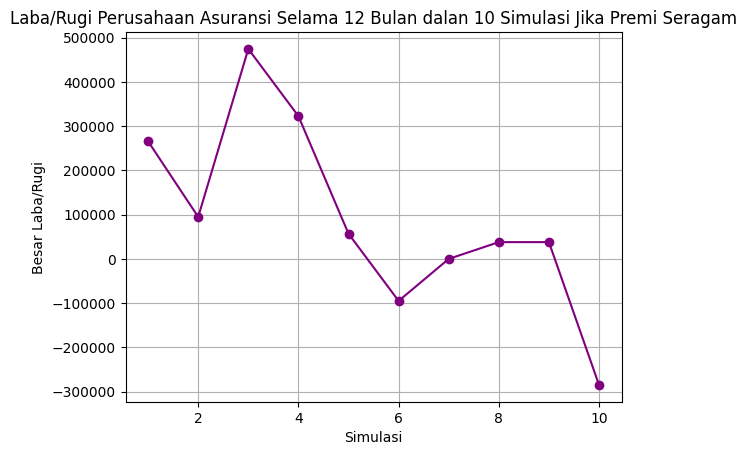

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

bulan = np.arange(1,11)
laba = [265766.81,94916.72,474583.58,322716.83,56950.03,-94916.73,0,37966.68,37966.67,-284750.16]
plt.plot(bulan,laba,"-o",color="purple")
plt.title("Laba/Rugi Perusahaan Asuransi Selama 12 Bulan dalan 10 Simulasi Jika Premi Seragam")
plt.xlabel("Simulasi")
plt.ylabel("Besar Laba/Rugi")
plt.grid()
plt.show()

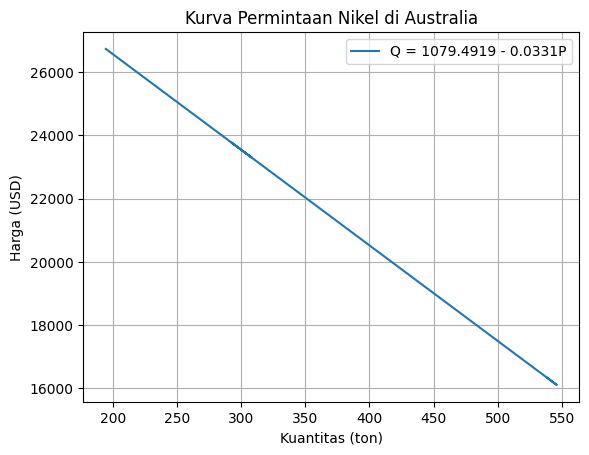

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
data_x = [26727,23288,23770,22134,21233,21091,20446,19644,18264,17027,16443,16111,16338]
data_kuantitas = [194.5342715,308.4029984,292.4434967,346.6130917,376.4461022,381.1478641,402.5044587,429.0594803,474.7526594,515.7109657,535.0477893,546.0406412,538.5244443]
plt.plot(data_kuantitas,data_x)
plt.title("Kurva Permintaan Nikel di Australia")
plt.xlabel("Kuantitas (ton)")
plt.ylabel("Harga (USD)")
plt.legend(["Q = 1079.4919 - 0.0331P"])
plt.grid()
plt.show()

Regresi Polinomial

In [ ]:
# Metode Least Squares
# variabel data_x dan data_y adalah data x dan y yang diketahui pada soal
# variabel data_x dan data_y dalam bentuk list / array
# x_input adalah variabel masukan yang ingin dicari nilai outputnya
# variabel order adalah derajat polinomial
# Bentuk persamaan regresi polinomial : y = β0 + β1 x + β2 x^2 + ... + βn x^n
# beta: koefisien regresi
# y_output : hasil prediksi untuk masukan x_input

import numpy as np

def polynom_reg(data_x, data_y, x_input, order):
  n = len(data_x)
  M = np.array([[0 for i in range (order + 1)] for j in range (n)])

  for j in range (order+1):
    for i in range (n):
      M[i][j] = data_x[i]**j

  beta = np.linalg.inv(M.T @ M) @ M.T @ data_y

  y_output = 0
  for i in range (order+1):
    y_output += beta[i]*x_input**i

  return y_output